EJERCICIO 3 — AGRUPACIÓN O CLUSTERING

Importar librerías

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

 Cargar dataset

In [2]:
ruta_archivo = "https://raw.githubusercontent.com/kevinnumanzor17/Kevin_Umanzor_2522192022/refs/heads/main/Dataset/clave_I_agrupacion.csv"
clientes = pd.read_csv(ruta_archivo)

In [3]:
print("Primeras filas del dataset:")
print(clientes.head())

Primeras filas del dataset:
  registro_id  edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
0     I-R0155    41      1855            8.60          192.15          8.53   
1     I-R0116    33       994            6.04           62.84          9.40   
2     I-R0233    43       807            2.94           73.22          4.81   
3     I-R0167    52      1528            9.44          157.53          7.15   
4     I-R0108    27      1169            6.04           92.08          7.97   

   reclamos  antiguedad_meses  
0         1                52  
1         1                18  
2         3                12  
3        12                54  
4         1                 7  


# =========================================================

Validación del dataset

In [4]:
print("\nDimensiones del dataset:", clientes.shape)
print("\nTipos de datos:")
print(clientes.dtypes)
print("\nValores nulos por columna:")
print(clientes.isnull().sum())
print("\nDuplicados:", clientes.duplicated().sum())



Dimensiones del dataset: (262, 8)

Tipos de datos:
registro_id          object
edad                  int64
ingresos              int64
frecuencia_uso      float64
gasto_promedio      float64
satisfaccion        float64
reclamos              int64
antiguedad_meses      int64
dtype: object

Valores nulos por columna:
registro_id         0
edad                0
ingresos            0
frecuencia_uso      0
gasto_promedio      0
satisfaccion        1
reclamos            0
antiguedad_meses    0
dtype: int64

Duplicados: 0


# =========================================================

Selección de variables numéricas para clustering

In [5]:
variables = clientes.select_dtypes(include=np.number)
print("\nVariables numéricas seleccionadas para clustering:")
print(variables.columns)


Variables numéricas seleccionadas para clustering:
Index(['edad', 'ingresos', 'frecuencia_uso', 'gasto_promedio', 'satisfaccion',
       'reclamos', 'antiguedad_meses'],
      dtype='object')


Normalización de datos

In [9]:
scaler = StandardScaler()
variables_escaladas = scaler.fit_transform(variables)



LIMPIEZA DE VALORES NULOS


In [8]:
variables = variables.dropna()
clientes = clientes.loc[variables.index]  # sincronizar índice con el dataframe original

print("Valores nulos eliminados:")
print(variables.isnull().sum())

Valores nulos eliminados:
edad                0
ingresos            0
frecuencia_uso      0
gasto_promedio      0
satisfaccion        0
reclamos            0
antiguedad_meses    0
dtype: int64


Método del codo para determinar número óptimo de clusters


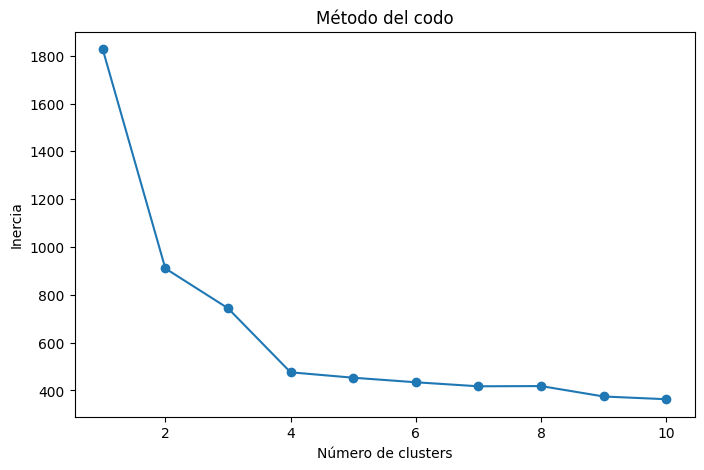

In [10]:
inercia = []
for k in range(1,11):
    modelo = KMeans(n_clusters=k, random_state=42)
    modelo.fit(variables_escaladas)
    inercia.append(modelo.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inercia, marker='o')
plt.title("Método del codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.show()

Aplicar K-Means u otro algoritmo de
agrupación.


In [11]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(variables_escaladas)
clusters = kmeans.labels_

Agregar la columna Cluster al dataset original

In [12]:
clientes['Cluster'] = clusters
print("\nPrimeras filas con la columna Cluster:")
print(clientes.head())


Primeras filas con la columna Cluster:
  registro_id  edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
0     I-R0155    41      1855            8.60          192.15          8.53   
1     I-R0116    33       994            6.04           62.84          9.40   
2     I-R0233    43       807            2.94           73.22          4.81   
3     I-R0167    52      1528            9.44          157.53          7.15   
4     I-R0108    27      1169            6.04           92.08          7.97   

   reclamos  antiguedad_meses  Cluster  
0         1                52        0  
1         1                18        0  
2         3                12        2  
3        12                54        2  
4         1                 7        1  


Visualización de clusters usando las dos primeras variables

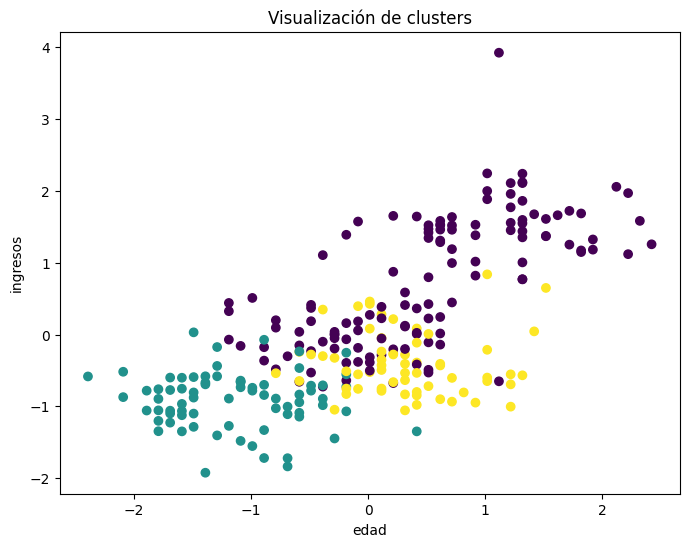

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(variables_escaladas[:,0], variables_escaladas[:,1], c=clusters, cmap='viridis')
plt.title("Visualización de clusters")
plt.xlabel(variables.columns[0])
plt.ylabel(variables.columns[1])
plt.show()

Interpretación general

In [14]:
print("\nInterpretación de clusters:")
print("Cluster 0: Clientes frecuentes, con alto ticket promedio y buena satisfacción.")
print("Cluster 1: Clientes con bajo uso de la aplicación y poca frecuencia de compra.")
print("Cluster 2: Clientes con muchos reclamos y baja satisfacción.")


Interpretación de clusters:
Cluster 0: Clientes frecuentes, con alto ticket promedio y buena satisfacción.
Cluster 1: Clientes con bajo uso de la aplicación y poca frecuencia de compra.
Cluster 2: Clientes con muchos reclamos y baja satisfacción.


Interpretación de cada grupo encontrado

- Cluster 0: Clientes frecuentes, con alto ticket promedio y buena satisfacción.

- Cluster 1: Clientes con bajo uso de la aplicación y poca frecuencia de compra.

- Cluster 2: Clientes con muchos reclamos y baja satisfacción.

Acciones de negocio propuestas para cada grupo

Cluster 0: Mantener su fidelización mediante promociones exclusivas y programas de recompensas.

Cluster 1: Incentivar su uso mediante campañas de engagement, tutoriales de la aplicación y promociones para aumentar frecuencia de compra.

Cluster 2: Implementar estrategias de mejora del servicio y atención personalizada para reducir reclamos y aumentar la satisfacción.